# CIBUSmod example
This notebook privides an example of using CIBUSmod to run a number of scenarios that represent different combinations of demand and production-side "intervetions". For more thorough explanations see 'run_scn.ipynb'

## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Run test scenario 'food-as-industry'

### Set up scenario and modules

Set path to folders containing all default and scenario data. Here we define a number of scenarios based on the same scenario Excel file but where we chose which madules and parameters are uppdated.

In [3]:
# Set paths to default and scenario data
cm.ParameterRetriever.set_data_folders(
    default = os.path.join('..','data','prod_parameters'),
    scenarios = os.path.join('..','data','scenarios'),
    relation_tables = os.path.join('..','data','relation_tables.xlsx')
)

# Define scenarios and create output container
session_name = 'food_as_industry_measures'
scenarios = {
    'baseline' : {
        'scenario' : None,
        'modules' : ['Regions','DemandAndConversions'],
        'pars' : 'all',
        'years' : ['2020']
    },
    
    'FAI (demand)' : {
        'scenario' : 'food_as_industry',
        'modules' : ['Regions','DemandAndConversions'],
        'pars' : ['max_land_use_factor','population','consumption','share_imported'],
        'years' : ['2050']
    },
    
    'FAI (+crop yields)' : {
        'scenario' : 'food_as_industry',
        'modules' : ['Regions','DemandAndConversions',
                     'CropProduction'],
        'pars' : ['max_land_use_factor','population','consumption','share_imported',
                 'yield'],
        'years' : ['2050']
    },
    
    'FAI (+milk yield)' : {
        'scenario' : 'food_as_industry',
        'modules' : ['Regions','DemandAndConversions',
                     'CropProduction','CattleHerd'],
        'pars' : ['max_land_use_factor','population','consumption','share_imported',
                 'yield','milk_prod'],
        'years' : ['2050']
    },
    
    'FAI (+beef productivity)' : {
        'scenario' : 'food_as_industry',
        'modules' : ['Regions','DemandAndConversions',
                     'CropProduction','CattleHerd'],
        'pars' : ['max_land_use_factor','population','consumption','share_imported',
                 'yield','milk_prod','slaughter_share_male_as_steers','slaughter_weight'],
        'years' : ['2050']
    },
    
    'FAI (+pork productivity)' : {
        'scenario' : 'food_as_industry',
        'modules' : ['Regions','DemandAndConversions',
                     'CropProduction','CattleHerd',
                    'PigHerd'],
        'pars' : ['max_land_use_factor','population','consumption','share_imported',
                 'yield','milk_prod','slaughter_share_male_as_steers','slaughter_weight',
                 'feed_energy_per_growth'],
        'years' : ['2050']
    },
    
    'FAI (+enteric methane)' : {
        'scenario' : 'food_as_industry',
        'modules' : ['Regions','DemandAndConversions',
                     'CropProduction','CattleHerd',
                    'PigHerd','FeedMgmt'],
        'pars' : ['max_land_use_factor','population','consumption','share_imported',
                 'yield','milk_prod','slaughter_share_male_as_steers','slaughter_weight',
                 'feed_energy_per_growth','enteric_adj'],
        'years' : ['2050']
    },
    
    'FAI (+electric field machinery)' : {
        'scenario' : 'food_as_industry',
        'modules' : ['Regions','DemandAndConversions',
                     'CropProduction','CattleHerd',
                    'PigHerd','FeedMgmt','MachineryAndEnergyMgmt'],
        'pars' : ['max_land_use_factor','population','consumption','share_imported',
                 'yield','milk_prod','slaughter_share_male_as_steers','slaughter_weight',
                 'feed_energy_per_growth','enteric_adj','energy_source_share'],
        'years' : ['2050']
    }
}

output = cm.Output()

Next, we initialise all model modules (python classes) that handle the calculations.

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever('ManureMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

### Run calculations

In [5]:
for scn in scenarios:
    scn_par = scenarios[scn].copy()
    years = scn_par.pop('years')
    # Loop through years
    for year in years:
        print(scn,year)

        # Update all parameter values
        cm.ParameterRetriever.update_all_parameter_values(
            **scn_par,
            year=year
        )

        # Get region attributes
        regions.calculate(verbose=True)

        # Calculate food demand
        demand.calculate(verbose=True)

        # Calculate crops
        crops.calculate(
            verbose = True
        )

        # Calculate herds
        for h in herds:
            h.calculate(verbose = True)

        # Calculate feed
        feed_mgmt.calculate(verbose=True)    

        # Distribute animals and crops
        # Make optimisation problem
        geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.6, verbose=True)
        # Solve optimisation problem
        geodist.solve(
            verbose=True,
            solver_settings = {
                'solver':'OSQP',
                'max_iter':200000,
                'eps_abs':5e-6,
                'eps_rel':5e-6,
                'verbose':False
            }
        )

        # Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
        feed_mgmt.calculate2(verbose=True)

        # Calculate manure
        manure_mgmt.calculate(verbose=True)

        # Calculate plant nutrient management
        plant_nutrient_mgmt.calculate(verbose=True)

        # Calculate energy requirements
        machinery_and_energy_mgmt.calculate(verbose=True)

        # Store results
        output.store(
            scn, year,
            demand, regions, crops, herds
        )

baseline 2020
[07:13:04][Regions] Getting initial crop areas and animal numbers (x0) ...
[07:13:04][Regions] Getting climate and soil attributes ...
[07:13:04][Regions] Calculating maximum land use ...
[07:13:04][Regions] Done! Elapsed time: 0 sec
[07:13:04][DemandAndConversions] Calculating food demand ...
[07:13:04][DemandAndConversions] Calculating waste ...
[07:13:04][DemandAndConversions] Calculating crop product demand ...
[07:13:05][DemandAndConversions] Calculating animal product demand ...
[07:13:05][DemandAndConversions] Done! Elapsed time: 1 sec
[07:13:05][CropProduction] Calculating harvest ...
[07:13:05][CropProduction] Calculating production ...
[07:13:08][CropProduction] Calculating crop residues ...
[07:13:08][CropProduction] Calculating seed demand ...
[07:13:08][CropProduction] Done! Elapsed time: 3 sec
[07:13:08][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[07:13:09][AnimalHerd (cattle, beef, conventional, maize based)] Calcul

[07:13:25][AnimalHerd (poultry, layer, organic, none)] Calculating production ...
[07:13:26][AnimalHerd (poultry, layer, organic, none)] Calculating feed energy or DM requirements ...
[07:13:26][AnimalHerd (poultry, layer, organic, none)] Done! Elapsed time: 0 sec
[07:13:26][FeedMgmt] Calculating feed consumption ...
[07:13:32][FeedMgmt] Calculating feed losses ...
[07:13:39][FeedMgmt] Calculating demand for crop products ...
[07:13:49][FeedMgmt] Calculating demand for by-products ...
[07:13:59][FeedMgmt] Done! Elapsed time: 34 sec
[07:13:59][GeoDistributor.make] Getting x0 and making indexes ...
[07:13:59][GeoDistributor.make] Creating demand vector ...
[07:14:00][GeoDistributor.make] Scaling ...
[07:14:00][GeoDistributor.make] Making objective O1 ...
[07:14:00][GeoDistributor.make] Making constraint C1 ...
[07:14:20][GeoDistributor.make] Making constraint C2 ...
[07:14:22][GeoDistributor.make] Making constraint C3 ...
[07:14:23][GeoDistributor.make] Making constraint C4 ...
[07:14:23

[07:16:46][AnimalHerd (horses, riding horses, organic, none)] Done! Elapsed time: 0 sec
[07:16:46][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating herd structure ...
[07:16:46][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating production ...
[07:16:46][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating feed energy or DM requirements ...
[07:16:47][AnimalHerd (horses, trotters and racehorses, conventional, none)] Done! Elapsed time: 0 sec
[07:16:47][AnimalHerd (horses, trotters and racehorses, organic, none)] Calculating herd structure ...
[07:16:47][AnimalHerd (horses, trotters and racehorses, organic, none)] Calculating production ...
[07:16:47][AnimalHerd (horses, trotters and racehorses, organic, none)] Calculating feed energy or DM requirements ...
[07:16:47][AnimalHerd (horses, trotters and racehorses, organic, none)] Done! Elapsed time: 0 sec
[07:16:47][AnimalHerd (pigs, none, conventional, none)

[07:20:18][AnimalHerd (cattle, dairy, conventional, none)] Calculating production ...
[07:20:18][AnimalHerd (cattle, dairy, conventional, none)] Calculating feed energy or DM requirements ...
[07:20:19][AnimalHerd (cattle, dairy, conventional, none)] Done! Elapsed time: 2 sec
[07:20:19][AnimalHerd (cattle, dairy, organic, none)] Calculating herd structure ...
[07:20:20][AnimalHerd (cattle, dairy, organic, none)] Calculating production ...
[07:20:20][AnimalHerd (cattle, dairy, organic, none)] Calculating feed energy or DM requirements ...
[07:20:22][AnimalHerd (cattle, dairy, organic, none)] Done! Elapsed time: 3 sec
[07:20:22][AnimalHerd (horses, cold blooded horses, conventional, none)] Calculating herd structure ...
[07:20:22][AnimalHerd (horses, cold blooded horses, conventional, none)] Calculating production ...
[07:20:23][AnimalHerd (horses, cold blooded horses, conventional, none)] Calculating feed energy or DM requirements ...
[07:20:23][AnimalHerd (horses, cold blooded horses, 

[07:23:09][PlantNutrientMgmt] Calculating N soil losses ...
[07:23:09][PlantNutrientMgmt] Done! Elapsed time: 8 sec
[07:23:09][MachineryAndEnergyMgmt] Calculating energy use in field machinery ...
[07:23:13][MachineryAndEnergyMgmt] Calculating energy use for grain drying (not implemented) ...
[07:23:13][MachineryAndEnergyMgmt] Calculating energy use in greenhouses ...
[07:23:15][MachineryAndEnergyMgmt] Calculating energy use in stables ...
[07:23:36][MachineryAndEnergyMgmt] Calculating fuel use emissions ...
[07:23:37][MachineryAndEnergyMgmt] Done! Elapsed time: 28 sec
FAI (+milk yield) 2050
[07:23:43][Regions] Getting initial crop areas and animal numbers (x0) ...
[07:23:43][Regions] Getting climate and soil attributes ...
[07:23:43][Regions] Calculating maximum land use ...
[07:23:43][Regions] Done! Elapsed time: 0 sec
[07:23:43][DemandAndConversions] Calculating food demand ...
[07:23:43][DemandAndConversions] Calculating waste ...
[07:23:43][DemandAndConversions] Calculating crop p

...

[07:27:22][AnimalHerd (horses, riding horses, conventional, none)] Done! Elapsed time: 0 sec
[07:27:22][AnimalHerd (horses, riding horses, organic, none)] Calculating herd structure ...
[07:27:22][AnimalHerd (horses, riding horses, organic, none)] Calculating production ...
[07:27:22][AnimalHerd (horses, riding horses, organic, none)] Calculating feed energy or DM requirements ...
[07:27:22][AnimalHerd (horses, riding horses, organic, none)] Done! Elapsed time: 0 sec
[07:27:22][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating herd structure ...
[07:27:22][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating production ...
[07:27:22][AnimalHerd (horses, trotters and racehorses, conventional, none)] Calculating feed energy or DM requirements ...
[07:27:23][AnimalHerd (horses, trotters and racehorses, conventional, none)] Done! Elapsed time: 0 sec
[07:27:23][AnimalHerd (horses, trotters and racehorses, organic, none)] Calculating herd 

[07:30:14][AnimalHerd (cattle, dairy, conventional, maize based)] Calculating production ...
[07:30:14][AnimalHerd (cattle, dairy, conventional, maize based)] Calculating feed energy or DM requirements ...
[07:30:15][AnimalHerd (cattle, dairy, conventional, maize based)] Done! Elapsed time: 1 sec
[07:30:15][AnimalHerd (cattle, dairy, conventional, none)] Calculating herd structure ...
[07:30:15][AnimalHerd (cattle, dairy, conventional, none)] Calculating production ...
[07:30:15][AnimalHerd (cattle, dairy, conventional, none)] Calculating feed energy or DM requirements ...
[07:30:16][AnimalHerd (cattle, dairy, conventional, none)] Done! Elapsed time: 1 sec
[07:30:16][AnimalHerd (cattle, dairy, organic, none)] Calculating herd structure ...
[07:30:16][AnimalHerd (cattle, dairy, organic, none)] Calculating production ...
[07:30:17][AnimalHerd (cattle, dairy, organic, none)] Calculating feed energy or DM requirements ...
[07:30:19][AnimalHerd (cattle, dairy, organic, none)] Done! Elapsed 

[07:32:08][ManureMgmt] Calculating N available to spread ...
[07:32:10][ManureMgmt] Done! Elapsed time: 20 sec
[07:32:10][PlantNutrientMgmt] Calculating crop N requirements ...
[07:32:13][PlantNutrientMgmt] Distributing manure ...
[07:32:17][PlantNutrientMgmt] Calculating mineral N application ...
[07:32:17][PlantNutrientMgmt] Calculating N in crop residues ...
[07:32:17][PlantNutrientMgmt] Calculating N application losses ...
[07:32:18][PlantNutrientMgmt] Calculating N soil losses ...
[07:32:18][PlantNutrientMgmt] Done! Elapsed time: 8 sec
[07:32:18][MachineryAndEnergyMgmt] Calculating energy use in field machinery ...
[07:32:22][MachineryAndEnergyMgmt] Calculating energy use for grain drying (not implemented) ...
[07:32:22][MachineryAndEnergyMgmt] Calculating energy use in greenhouses ...
[07:32:23][MachineryAndEnergyMgmt] Calculating energy use in stables ...
[07:32:48][MachineryAndEnergyMgmt] Calculating fuel use emissions ...
[07:32:49][MachineryAndEnergyMgmt] Done! Elapsed time: 

[07:33:20][AnimalHerd (poultry, broiler, conventional, none)] Calculating feed energy or DM requirements ...
[07:33:20][AnimalHerd (poultry, broiler, conventional, none)] Done! Elapsed time: 0 sec
[07:33:20][AnimalHerd (poultry, broiler, organic, none)] Calculating herd structure ...
[07:33:20][AnimalHerd (poultry, broiler, organic, none)] Calculating production ...
[07:33:21][AnimalHerd (poultry, broiler, organic, none)] Calculating feed energy or DM requirements ...
[07:33:21][AnimalHerd (poultry, broiler, organic, none)] Done! Elapsed time: 0 sec
[07:33:21][AnimalHerd (poultry, layer, conventional, none)] Calculating herd structure ...
[07:33:21][AnimalHerd (poultry, layer, conventional, none)] Calculating production ...
[07:33:21][AnimalHerd (poultry, layer, conventional, none)] Calculating feed energy or DM requirements ...
[07:33:21][AnimalHerd (poultry, layer, conventional, none)] Done! Elapsed time: 1 sec
[07:33:21][AnimalHerd (poultry, layer, organic, none)] Calculating herd s

[07:36:12][AnimalHerd (horses, ponies and Icelandic horses, conventional, none)] Done! Elapsed time: 0 sec
[07:36:12][AnimalHerd (horses, ponies and Icelandic horses, organic, none)] Calculating herd structure ...
[07:36:12][AnimalHerd (horses, ponies and Icelandic horses, organic, none)] Calculating production ...
[07:36:12][AnimalHerd (horses, ponies and Icelandic horses, organic, none)] Calculating feed energy or DM requirements ...
[07:36:12][AnimalHerd (horses, ponies and Icelandic horses, organic, none)] Done! Elapsed time: 0 sec
[07:36:12][AnimalHerd (horses, riding horses, conventional, none)] Calculating herd structure ...
[07:36:12][AnimalHerd (horses, riding horses, conventional, none)] Calculating production ...
[07:36:12][AnimalHerd (horses, riding horses, conventional, none)] Calculating feed energy or DM requirements ...
[07:36:12][AnimalHerd (horses, riding horses, conventional, none)] Done! Elapsed time: 0 sec
[07:36:12][AnimalHerd (horses, riding horses, organic, none

## Save results to file
We can write results to a binary file using pickle for future use.

In [6]:
# Write file
# This may take a while if compression is used (.bz2 file extension)
output.save_file('out_'+session_name+'.bz2')

In [7]:
# Read file
output = cm.Output.from_file('out_'+session_name+'.bz2')

### Look at the data

In [8]:
output.info()

*-----------------*
| CIBUSmod Output |
*-----------------*

Scenarios
---------
baseline: 2020 
FAI (demand): 2050 
FAI (+crop yields): 2050 
FAI (+milk yield): 2050 
FAI (+beef productivity): 2050 
FAI (+pork productivity): 2050 
FAI (+enteric methane): 2050 
FAI (+electric field machinery): 2050 

DemandAndConversions
--------------------
Data attributes:
waste, animal_prod_demand, animal_by_products, food_demand_to_processing, crop_prod_demand, crop_by_products, population, non_food_demand, food_demand, export_demand


Regions
-------
Data attributes:
max_land_use, soil, climate, x0_animals, x0_crops


CropProduction
--------------
Data attributes:
production_per_use, fertiliser.crop_residues_N, production, fertiliser.mineral_N_application_loss, fertiliser.crop_residues_N_soil_loss, fertiliser.manure_N_soil_loss, fertiliser.organic_soil_N_loss, harvest_dm, fertiliser.manure_C, crop_residues, harvested_crop_residues, energy_use_emissions, fertiliser.manure_TAN, harvest, fertiliser.m

## Plot output
Here are some example output plots.

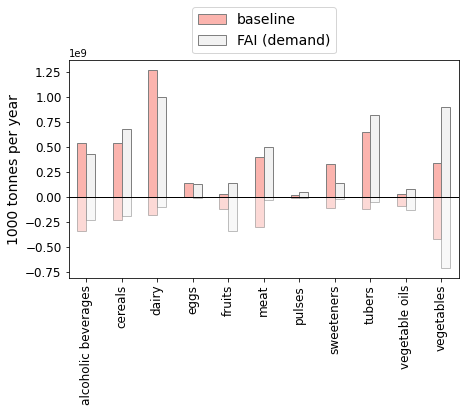

In [11]:
plot_data = (
    cm.get_attr(output.loc[['baseline','FAI (demand)']],'D','food_demand_to_processing',['origin','food_group'])
    .stack()
    .droplevel('year')
)
plot_data.loc[:,'imported'] = -plot_data.loc[:,'imported']

fig, ax = plt.subplots(figsize=(7,4))
plot_data['domestic'].unstack('scn').plot(kind='bar', cmap='Pastel1', edgecolor='grey', ax=ax)
(
    plot_data['imported'].unstack('scn')
    .rename({x:'_' for x in plot_data.index.get_level_values('scn').unique()}, axis=1)
).plot(kind='bar', cmap='Pastel1', edgecolor='grey', ax=ax, legend=False, alpha=0.5)

plt.hlines(0,-1,11, color='black', linewidth=1)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_ylabel('1000 tonnes per year', size=14)
ax.set_xlabel('')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1), fontsize=14)

plt.show()

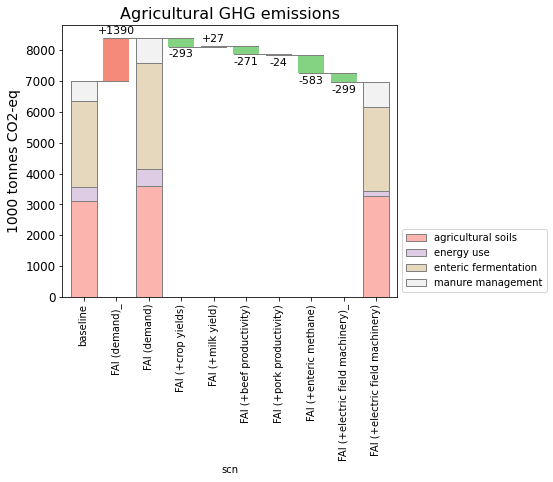

In [12]:
fig, ax = plt.subplots(figsize=(6,5))

plot_data1 = (
    cm.get_GHG(output)
    .sum()
    .groupby(['scn','process'])
    .sum()
    .unstack()
    .reindex(pd.Index(scenarios.keys(),name='scn'))
)/1000000

plot.waterfall(
    data=plot_data1,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.set_title('Agricultural GHG emissions', size=16)
ax.tick_params(axis='y', which='major', labelsize=12)
ax.set_ylabel('1000 tonnes CO2-eq', size=14)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.show()

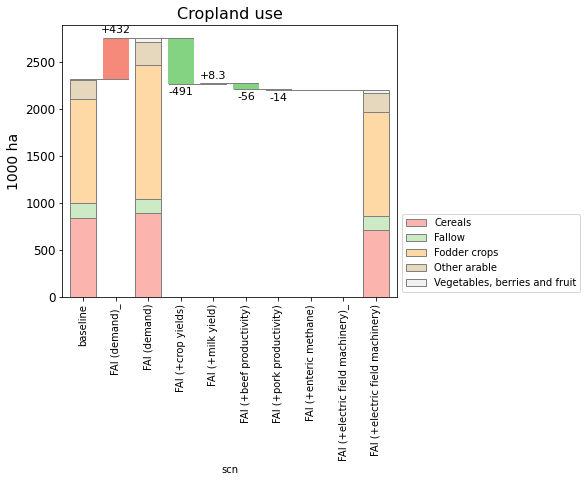

In [13]:
fig, ax = plt.subplots(figsize=(6,5))

plot_data2 = (
    (output.get_attr('C','area',groupby={'crop':'crop_group2'})/1000)
    .drop(['Greenhouse crops','Semi-natural grasslands'], axis=1)
    .droplevel('year')
)

plot.waterfall(
    data=plot_data2,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.set_title('Cropland use', size=16)
ax.tick_params(axis='y', which='major', labelsize=12)
ax.set_ylabel('1000 ha', size=14)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.show()

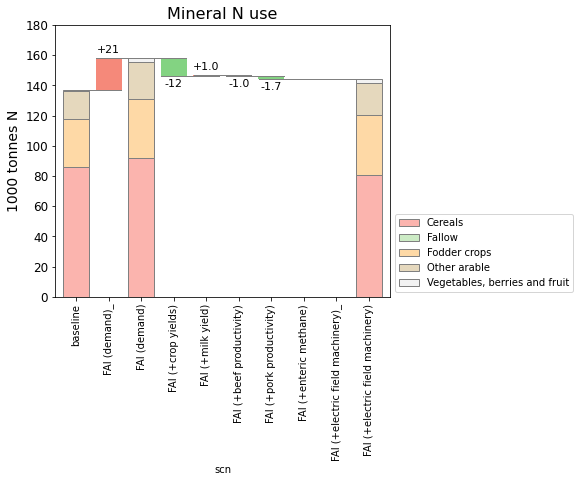

In [14]:
fig, ax = plt.subplots(figsize=(6,5))

plot_data3 = (
    (output.get_attr('C','fertiliser.mineral_N',groupby={'crop':'crop_group2'})/1000000)
    .drop(['Greenhouse crops','Semi-natural grasslands'], axis=1)
    .droplevel('year')
)

plot.waterfall(
    data=plot_data3,
    ax=ax,
    breaks = ['FAI (demand)'],
    cmap='Pastel1',
    edgecolor='grey',
    width=0.8,
    label='absolute'
)

ax.set_title('Mineral N use', size=16)
ax.tick_params(axis='y', which='major', labelsize=12)
ax.set_ylabel('1000 tonnes N', size=14)
ax.set_ylim(0,180)
ax.legend(loc='lower left', bbox_to_anchor=(1, 0))

plt.show()